# 01_eda.ipynb — Titanic exploratory data analysis

This notebook loads the Titanic dataset (using seaborn.load_dataset exactly once), saves it to `titanic.csv`, and performs the EDA steps required: info/describe/shape, missingness analysis and rule-based handling, visualizations, correlation heatmap, z-score checks, and several story charts with Markdown placeholders for interpretation.

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set(style='whitegrid')


In [2]:
# Load the titanic dataset exactly once and save the raw CSV
try:
    df = sns.load_dataset('titanic')
    print('Loaded titanic via seaborn.load_dataset')
except Exception as e:
    print('seaborn.load_dataset failed:', e)
    # Fallbacks: 1) local analytics/titanic.csv if present, 2) attempt direct download using requests with certifi bundle
    import pathlib, requests, certifi
    local = pathlib.Path('titanic.csv')
    if local.exists():
        df = pd.read_csv(local)
        print('Loaded titanic from local titanic.csv')
    else:
        url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
        print('Attempting to download titanic.csv using requests with certifi bundle')
        r = requests.get(url, timeout=30, verify=certifi.where())
        r.raise_for_status()
        open('titanic.csv','wb').write(r.content)
        df = pd.read_csv('titanic.csv')
        print('Downloaded and saved titanic.csv')
# Save a canonical raw copy as required by the spec
df.to_csv('titanic.csv', index=False)
print('Saved titanic.csv with shape:', df.shape)


seaborn.load_dataset failed: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1082)>
Loaded titanic from local titanic.csv
Saved titanic.csv with shape: (891, 15)


## Basic information and summaries

In [3]:
# Basic profiling
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Describe (numeric + object summary):')
print(df.describe(include='all'))


Shape: (891, 15)

Dtypes:
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

Describe (numeric + object summary):
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420

## Missingness analysis and rule-based decisions

In [4]:
# Missing percent per column
missing_pct = df.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print('Columns with missing values and percentage:')
print(missing_pct)

# Apply the rule: <5% drop rows, 5-30% impute, >30% drop column or use 'Missing' category
decisions = {}
n = len(df)
for col, pct in missing_pct.items():
    if pct < 5:
        decisions[col] = (pct, 'drop-rows')
    elif pct <= 30:
        decisions[col] = (pct, 'impute')
    else:
        decisions[col] = (pct, 'drop-or-missing-category')

print()
print('Applied decisions (column: (missing%, action)):')
for k,v in decisions.items():
    print(k, ':', v)


Columns with missing values and percentage:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64

Applied decisions (column: (missing%, action)):
deck : (77.21661054994388, 'drop-or-missing-category')
age : (19.865319865319865, 'impute')
embarked : (0.22446689113355783, 'drop-rows')
embark_town : (0.22446689113355783, 'drop-rows')


*For each decision above, please justify the choice. (User to fill in)*

## Age and Fare: distributions, IQR outliers, and basic statistics


Column: age
IQR: 17.875, outliers count: 11


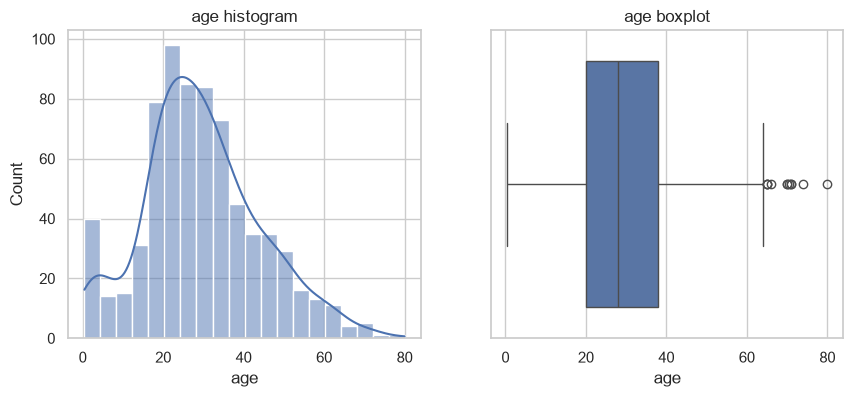


Column: fare
IQR: 23.090, outliers count: 116


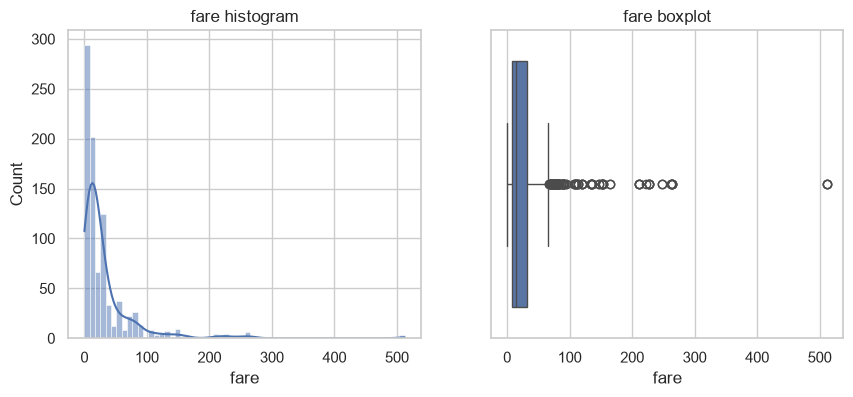


Fare mean: 32.204207968574636 median: 14.4542 mode: 8.05
Skew (pearson): 4.7792532923723545

Z-score check for age: mean 0.000, std 1.000

Z-score check for fare: mean 0.000, std 1.000


In [5]:
for col in ['age','fare']:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    print()
    print('Column: {}'.format(col))
    print('IQR: {:.3f}, outliers count: {}'.format(iqr, len(outliers)))
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(series, kde=True)
    plt.title(f"{col} histogram")
    plt.subplot(1,2,2)
    sns.boxplot(x=series)
    plt.title(f"{col} boxplot")
    plt.show()

# mean/median/mode of fare and skew conclusion
fare = df['fare'].dropna()
print()
print('Fare mean:', fare.mean(), 'median:', fare.median(), 'mode:', fare.mode().iloc[0])
print('Skew (pearson):', stats.skew(fare.dropna()))

# z-score standardization check for age and fare
for col in ['age','fare']:
    vals = df[col].dropna()
    z = (vals - vals.mean()) / vals.std(ddof=0)
    print()
    print('Z-score check for {}: mean {:.3f}, std {:.3f}'.format(col, z.mean(), z.std(ddof=0)))


## Survival rates by sex, pclass, and sex+pclass (using boolean masks)

In [6]:
print('Overall survival rate:', df['survived'].mean())

mask_male = (df['sex'] == 'male')
mask_female = (df['sex'] == 'female')
print()
print('Survival rate (male):', df.loc[mask_male, 'survived'].mean())
print('Survival rate (female):', df.loc[mask_female, 'survived'].mean())

for p in sorted(df['pclass'].dropna().unique()):
    print(f"Survival rate (pclass={p}):", df.loc[df['pclass'] == p, 'survived'].mean())

print()
print('Survival by sex and pclass:')
print(df.groupby(['sex','pclass'])['survived'].mean())


Overall survival rate: 0.3838383838383838

Survival rate (male): 0.18890814558058924
Survival rate (female): 0.7420382165605095
Survival rate (pclass=1): 0.6296296296296297
Survival rate (pclass=2): 0.47282608695652173
Survival rate (pclass=3): 0.24236252545824846

Survival by sex and pclass:
sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


## Correlation matrix (survived, pclass, age, sibsp, parch, fare) and top two pairs

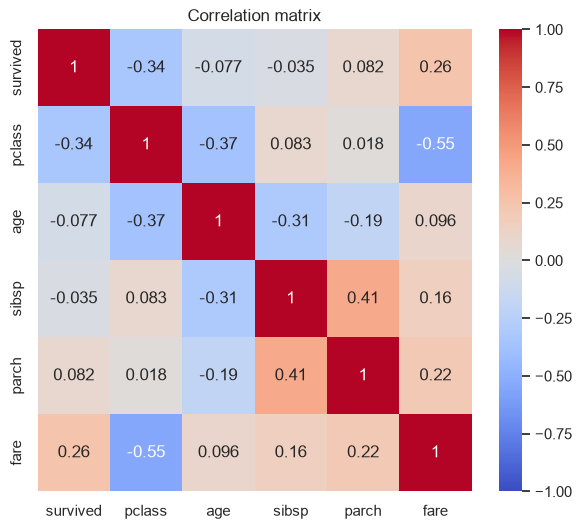


Top two pairs by absolute correlation:
('pclass', 'fare') 0.5494996199439075
('sibsp', 'parch') 0.41483769862015635


In [7]:
corr_cols = ['survived','pclass','age','sibsp','parch','fare']
corr = df[corr_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

pairs = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        pairs.append(((corr_cols[i], corr_cols[j]), abs(corr.iloc[i,j])))
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)
print()
print('Top two pairs by absolute correlation:')
for p,v in pairs_sorted[:2]:
    print(p, v)


## Story charts (4) — each followed by an empty interpretation cell

Charts below illustrate key patterns; please write interpretations in the following Markdown cells with 2-4 sentences each.

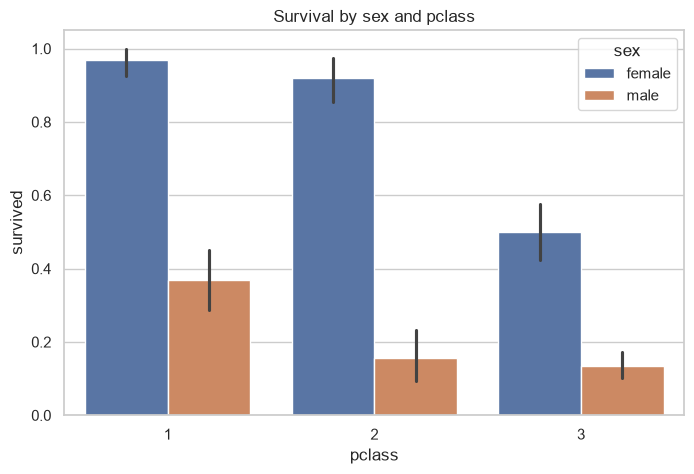

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Survival by sex and pclass')
plt.show()


### Interpretation (2-4 sentences)

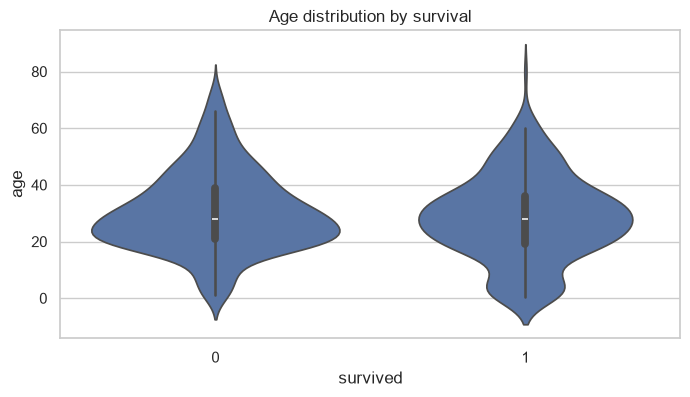

In [9]:
plt.figure(figsize=(8,4))
sns.violinplot(x='survived', y='age', data=df)
plt.title('Age distribution by survival')
plt.show()


### Interpretation (2-4 sentences)

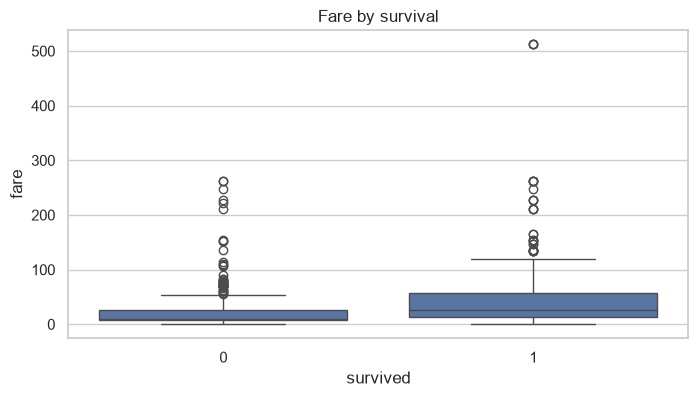

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare by survival')
plt.show()


### Interpretation (2-4 sentences)

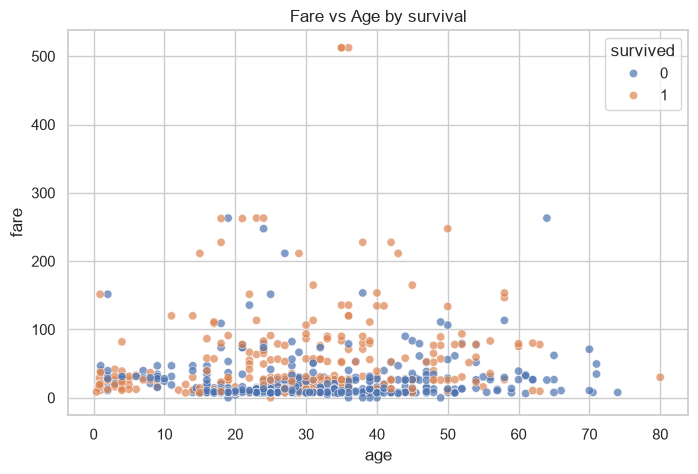

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='fare', hue='survived', data=df, alpha=0.7)
plt.title('Fare vs Age by survival')
plt.show()


### Interpretation (2-4 sentences)

## Z-score standardization check for age and fare (before and after)

In [12]:
from sklearn.preprocessing import StandardScaler
summary = []
for col in ['age','fare']:
    vals = df[col].dropna()
    before_mean = vals.mean()
    before_std = vals.std(ddof=0)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(vals.values.reshape(-1,1)).flatten()
    after_mean = scaled.mean()
    after_std = scaled.std(ddof=0)
    summary.append({'column':col,'before_mean':before_mean,'before_std':before_std,'after_mean':after_mean,'after_std':after_std})

summary_df = pd.DataFrame(summary)
print(summary_df)


  column  before_mean  before_std    after_mean  after_std
0    age    29.699118   14.516321  2.338621e-16        1.0
1   fare    32.204208   49.665534  3.987333e-18        1.0


## Save cleaned DataFrame (optional)

The raw `titanic.csv` was saved earlier. Below is an example of applying the missingness decisions programmatically and saving a cleaned version for downstream modeling. The raw file is preserved as required.

In [13]:
# Apply simple cleaning based on earlier decisions: drop rows with very small missingness (<5%), impute median for moderate missingness (5-30%).
clean = df.copy()
if 'age' in clean.columns:
    clean['age'] = clean['age'].fillna(clean['age'].median())
if 'embarked' in clean.columns:
    if clean['embarked'].isna().mean() * 100 < 5:
        clean = clean.dropna(subset=['embarked'])
    else:
        clean['embarked'] = clean['embarked'].fillna('Missing')
clean.to_csv('titanic_cleaned.csv', index=False)
print('Saved titanic_cleaned.csv with shape', clean.shape)


Saved titanic_cleaned.csv with shape (889, 15)
